# Raman predictions vs DFT spectra

This notebook loads model predictions from `raman_outputs.csv` and compares them to DFT Raman spectra stored in `molecule.db`. 
DFT data are line spectra (frequencies + Raman activities), so we broaden them to a smooth curve and overlay against the model output.


In [1]:
import json
import sqlite3
import zlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

In [2]:
def _parse_response_json(text):
    """Parse model response JSON into numpy arrays."""
    if not isinstance(text, str):
        return None, None
    data = json.loads(text)
    x = np.array(data.get('x', []), dtype=float)
    y = np.array(data.get('y', []), dtype=float)
    if x.size == 0 or y.size == 0:
        return None, None
    return x, y


def load_predictions(csv_path):
    """Load predictions CSV and attach parsed spectra arrays."""
    df = pd.read_csv(csv_path)
    df = df[df['ok'] == 1].copy()
    parsed = df['response_json'].apply(_parse_response_json)
    df['pred_x'] = parsed.apply(lambda v: v[0])
    df['pred_y'] = parsed.apply(lambda v: v[1])
    df = df[df['pred_x'].map(lambda v: v is not None and len(v) > 0)]
    return df


def load_dft_blob(blob):
    """Decompress the zlib JSON blob stored in molecule.db."""
    if blob is None:
        return None
    raw = zlib.decompress(blob)
    return json.loads(raw)


def get_dft_freqs_intensities(conn, molecule_id):
    """Fetch DFT line spectrum for a molecule id."""
    row = conn.execute("SELECT blob_data FROM molecule WHERE id = ?", (int(molecule_id),)).fetchone()
    if not row:
        return None, None
    data = load_dft_blob(row[0])
    if not data:
        return None, None
    freqs = np.array(data.get('freq', data.get('2', [])), dtype=float)
    intensities = np.array(data.get('Raman Activ', data.get('6', [])), dtype=float)
    return freqs, intensities


def lorentzian_spectrum(freqs, intensities, x_grid, gamma=10.0):
    """Lorentzian broadening for line spectra."""
    spectrum = np.zeros_like(x_grid, dtype=float)
    if freqs is None or intensities is None:
        return spectrum
    for f, i in zip(freqs, intensities):
        spectrum += i * (gamma ** 2 / ((x_grid - f) ** 2 + gamma ** 2))
    return spectrum


def gaussian_spectrum(freqs, intensities, x_grid, sigma=10.0):
    """Gaussian broadening for line spectra."""
    spectrum = np.zeros_like(x_grid, dtype=float)
    if freqs is None or intensities is None:
        return spectrum
    if sigma <= 0:
        return spectrum
    coef = 1.0 / (2.0 * sigma ** 2)
    for f, i in zip(freqs, intensities):
        spectrum += i * np.exp(-((x_grid - f) ** 2) * coef)
    return spectrum


def broaden_spectrum(freqs, intensities, x_grid, width=10.0, kernel='gaussian'):
    """Apply the requested broadening kernel to line spectra."""
    kernel = (kernel or 'gaussian').lower()
    if kernel == 'gaussian':
        return gaussian_spectrum(freqs, intensities, x_grid, sigma=width)
    if kernel == 'lorentzian':
        return lorentzian_spectrum(freqs, intensities, x_grid, gamma=width)
    raise ValueError(f'Unknown kernel: {kernel}')


def normalize(y):
    """Scale spectrum to max=1 for shape comparison."""
    y = np.asarray(y, dtype=float)
    peak = np.nanmax(y)
    if not np.isfinite(peak) or peak == 0:
        return y
    return y / peak


def spectral_metrics(y_pred, y_true):
    """Compute simple similarity metrics on aligned spectra."""
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    diff = y_pred - y_true
    mse = np.nanmean(diff ** 2)
    mae = np.nanmean(np.abs(diff))
    if np.nanstd(y_pred) > 0 and np.nanstd(y_true) > 0:
        pearson = np.corrcoef(y_pred, y_true)[0, 1]
    else:
        pearson = np.nan
    denom = np.linalg.norm(y_pred) * np.linalg.norm(y_true)
    cosine = float(np.dot(y_pred, y_true) / denom) if denom > 0 else np.nan
    return {"mse": mse, "mae": mae, "pearson": pearson, "cosine": cosine}



In [3]:
# Paths (update these if you move the files)
csv_path = 'raman_outputs.csv'
db_path = 'molecule.db'

pred_df = load_predictions(csv_path)
print(f'Loaded {len(pred_df)} successful predictions')
pred_df.head()


Loaded 103 successful predictions


,id,smiles,database_tag,ok,error,response_json,pred_x,pred_y
0,1,N#Cc1ccc2c(c1)[C@@H](N1CCCC1=O)[C@@H](C(O2)(C)C)O,"C,h,e,m,B,L,/,1",1,NaN,"{""x"":[500.0,501.0,502.0,503.0,504.0,505.0,506....","[500.0, 501.0, 502.0, 503.0, 504.0, 505.0, 506...","[0.027821880615865966, 0.029356496678465592, 0..."
1,2,CCC[C@@H]1C(=C(C)N=C(/C/1=C(/OC)\O)C)C(=O)OCC,"C,h,e,m,B,L,/,1",1,NaN,"{""x"":[500.0,501.0,502.0,503.0,504.0,505.0,506....","[500.0, 501.0, 502.0, 503.0, 504.0, 505.0, 506...","[0.055107652113033194, 0.056436082440724414, 0..."
2,3,CCO/C(=C\1/C(=NC(=C([C@H]1C)C(=O)OCCSc1ccccc1)...,"C,h,e,m,B,L,/,1",1,NaN,"{""x"":[500.0,501.0,502.0,503.0,504.0,505.0,506....","[500.0, 501.0, 502.0, 503.0, 504.0, 505.0, 506...","[0.051622104083580866, 0.051805615861487526, 0..."
3,4,NCCCC[C@H](C(=O)N[C@H](C(=O)CCC(=O)N1CCC[C@H]1...,"C,h,e,m,B,L,/,1",1,NaN,"{""x"":[500.0,501.0,502.0,503.0,504.0,505.0,506....","[500.0, 501.0, 502.0, 503.0, 504.0, 505.0, 506...","[0.15952781029551896, 0.158898103995238, 0.157..."
4,5,NCCCNCCCCN(C(=O)CC(=O)NCCCCCC[N]C(=[NH2])N)C,"C,h,e,m,B,L,/,1",1,NaN,"{""x"":[500.0,501.0,502.0,503.0,504.0,505.0,506....","[500.0, 501.0, 502.0, 503.0, 504.0, 505.0, 506...","[0.10968014345538875, 0.10328427253239957, 0.0..."


In [4]:
# Select which prediction to compare.
# - row_index uses the row number in raman_outputs.csv (after ok==1 filtering).
# - molecule_id uses the dataset id and searches the predictions by id.
# - smiles_query matches the exact SMILES string in the predictions file.
row_index = 0
molecule_id = None
smiles_query = None

def select_prediction(pred_df, row_index=None, molecule_id=None, smiles=None):
    """Pick a prediction row by index, molecule id, or SMILES."""
    if smiles is not None:
        matches = pred_df[pred_df['smiles'] == smiles]
        if matches.empty:
            raise ValueError(f'No prediction found for smiles: {smiles}')
        return matches.iloc[0]

    if molecule_id is not None:
        matches = pred_df[pred_df['id'] == int(molecule_id)]
        if matches.empty:
            raise ValueError(f'No prediction found for id: {molecule_id}')
        return matches.iloc[0]

    if row_index is not None:
        return pred_df.iloc[int(row_index)]

    raise ValueError('Provide row_index, molecule_id, or smiles_query.')


def build_comparison(row, db_path, width, freq_scale=1.0, kernel='gaussian'):
    """Load DFT data for the selected prediction and build aligned spectra."""
    molecule_id = int(row['id'])
    x_pred = row['pred_x']
    y_pred = normalize(row['pred_y'])

    with sqlite3.connect(db_path) as conn:
        freqs, intensities = get_dft_freqs_intensities(conn, molecule_id)

    if freqs is None:
        raise ValueError(f'No DFT spectrum found for id: {molecule_id}')

    y_dft = broaden_spectrum(freqs * freq_scale, intensities, x_pred, width=width, kernel=kernel)
    y_dft = normalize(y_dft)
    return molecule_id, x_pred, y_pred, y_dft


# Broadening settings; use try/except so tuning cells can override.
try:
    width
except NameError:
    width = 10.0  # cm^-1, used as sigma for Gaussian

try:
    kernel
except NameError:
    kernel = 'gaussian'  # 'gaussian' or 'lorentzian'

# Frequency scaling for DFT lines; adjust if the DFT looks horizontally squashed.
try:
    freq_scale
except NameError:
    freq_scale = 0.93

row = select_prediction(pred_df, row_index=row_index, molecule_id=molecule_id, smiles=smiles_query)
example_id, x_pred, y_pred, y_dft = build_comparison(row, db_path, width, freq_scale, kernel)
metrics = spectral_metrics(y_pred, y_dft)
metrics





{'mse': np.float64(0.015223600566680758),
 'mae': np.float64(0.045010339853029185),
 'pearson': np.float64(-0.016887457891392264),
 'cosine': 0.08198771486577532}

## Method notes
- DFT data in `molecule.db` are line spectra (mode frequencies + Raman activities).
- We convert lines into a continuous spectrum with configurable broadening
  (Gaussian or Lorentzian; width in cm^-1).
- Both spectra are normalized to max=1 to compare shape rather than absolute scale.
- We can tune frequency scale and broadening width via a small grid search.
- The optional tuner below grid-searches scale/width/kernel using masked Pearson
  correlation on a sample to emphasize peak regions.


In [5]:
# Optional: tune frequency scale and broadening to better match the model.
# Run this cell, then re-run the selection/plot cell above.
scale_grid = np.arange(0.90, 1.01, 0.005)
width_grid = np.arange(6.0, 21.0, 2.0)
kernel_grid = ['gaussian', 'lorentzian']
sample_size = 30
top_quantile = 0.85

def masked_pearson(y_pred, y_true, top_quantile=0.85):
    """Pearson correlation focusing on the high-intensity region."""
    y_pred = np.asarray(y_pred, dtype=float)
    y_true = np.asarray(y_true, dtype=float)
    thresh_pred = np.quantile(y_pred, top_quantile)
    thresh_true = np.quantile(y_true, top_quantile)
    mask = (y_pred >= thresh_pred) | (y_true >= thresh_true)
    if mask.sum() < 3:
        return np.nan
    a = y_pred[mask]
    b = y_true[mask]
    if np.nanstd(a) == 0 or np.nanstd(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]


def tune_scale_and_width(pred_df, db_path, scale_grid, width_grid, kernel_grid, sample_size=30, top_quantile=0.85):
    """Grid search to maximize masked Pearson correlation."""
    sample = pred_df.sample(n=min(sample_size, len(pred_df)), random_state=0)
    results = []

    with sqlite3.connect(db_path) as conn:
        for kernel in kernel_grid:
            for width in width_grid:
                for scale in scale_grid:
                    scores = []
                    for _, row in sample.iterrows():
                        molecule_id = int(row['id'])
                        x_pred = row['pred_x']
                        y_pred = normalize(row['pred_y'])

                        freqs, intensities = get_dft_freqs_intensities(conn, molecule_id)
                        if freqs is None:
                            continue

                        y_dft = broaden_spectrum(freqs * scale, intensities, x_pred, width=width, kernel=kernel)
                        y_dft = normalize(y_dft)

                        score = masked_pearson(y_pred, y_dft, top_quantile=top_quantile)
                        if np.isfinite(score):
                            scores.append(score)

                    results.append({
                        'kernel': kernel,
                        'width': float(width),
                        'scale': float(scale),
                        'mean_masked_pearson': float(np.nanmean(scores)),
                        'n': int(len(scores)),
                    })

    summary = pd.DataFrame(results)
    summary = summary.sort_values('mean_masked_pearson', ascending=False)
    return summary


tuning_summary = tune_scale_and_width(
    pred_df, db_path, scale_grid, width_grid, kernel_grid,
    sample_size=sample_size, top_quantile=top_quantile,
)
best = tuning_summary.iloc[0]
kernel = str(best['kernel'])
width = float(best['width'])
freq_scale = float(best['scale'])
print(f'Best kernel={kernel}, width={width:.2f}, scale={freq_scale:.3f}')
tuning_summary.head(5)


Best kernel=gaussian, width=6.00, scale=0.900


,kernel,width,scale,mean_masked_pearson,n
0,gaussian,6.0,0.900,-0.261994,30
1,gaussian,6.0,0.905,-0.264715,30
2,gaussian,6.0,0.910,-0.266942,30
3,gaussian,6.0,0.915,-0.267994,30
4,gaussian,6.0,0.920,-0.268260,30


In [6]:
# Plot overlay for the selected molecule
def plot_spectra(example_id, x_pred, y_pred, y_dft):
    plt.figure(figsize=(10, 4))
    plt.plot(x_pred, y_pred, label='Model prediction', linewidth=1.5)
    plt.plot(x_pred, y_dft, label='DFT (broadened)', linewidth=1.5, alpha=0.8)
    plt.xlabel('Wavenumber (cm$^{-1}$)')
    plt.ylabel('Normalized intensity')
    plt.title(f'Raman comparison for molecule id {example_id}')
    plt.legend()
    plt.tight_layout()
    plt.show()

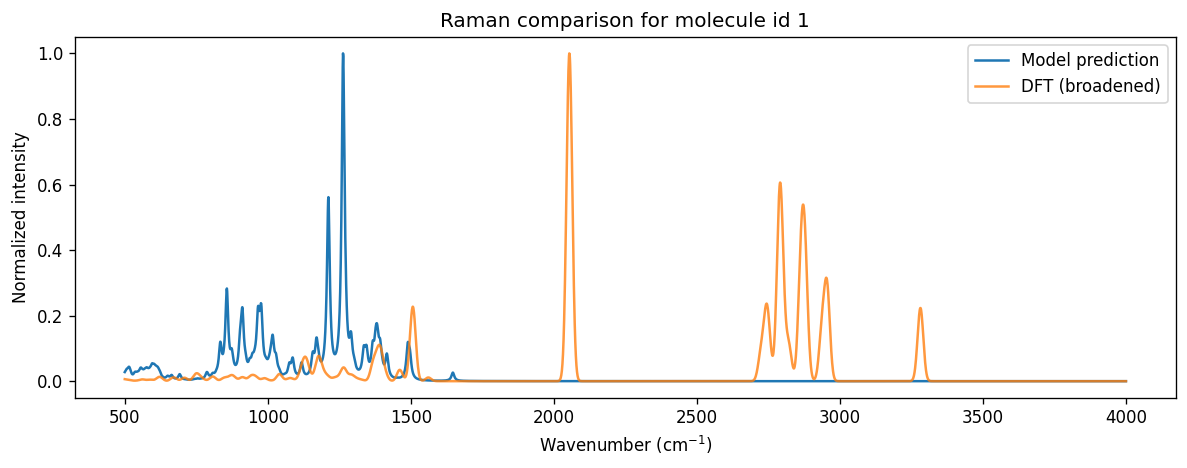

In [7]:
# Plot overlay for the selected molecule
plot_spectra(example_id, x_pred, y_pred, y_dft)


row=0 id=1 metrics={'mse': np.float64(0.010908219197186321), 'mae': np.float64(0.036843668003634596), 'pearson': np.float64(-0.034448354147035315), 'cosine': 0.04748453264806791}


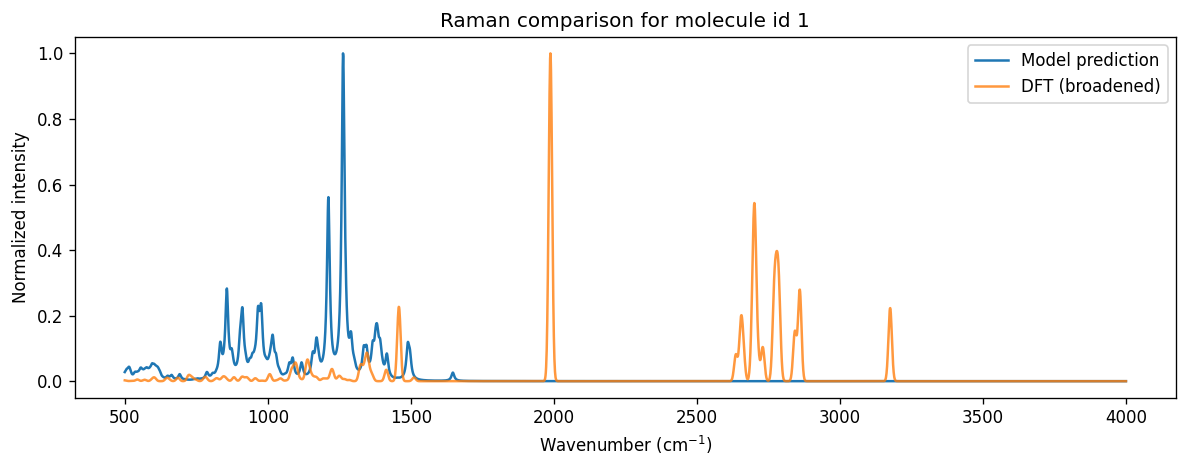

row=1 id=2 metrics={'mse': np.float64(0.01467526980520799), 'mae': np.float64(0.0479542408380142), 'pearson': np.float64(0.2751738844957676), 'cosine': 0.3560489863604781}


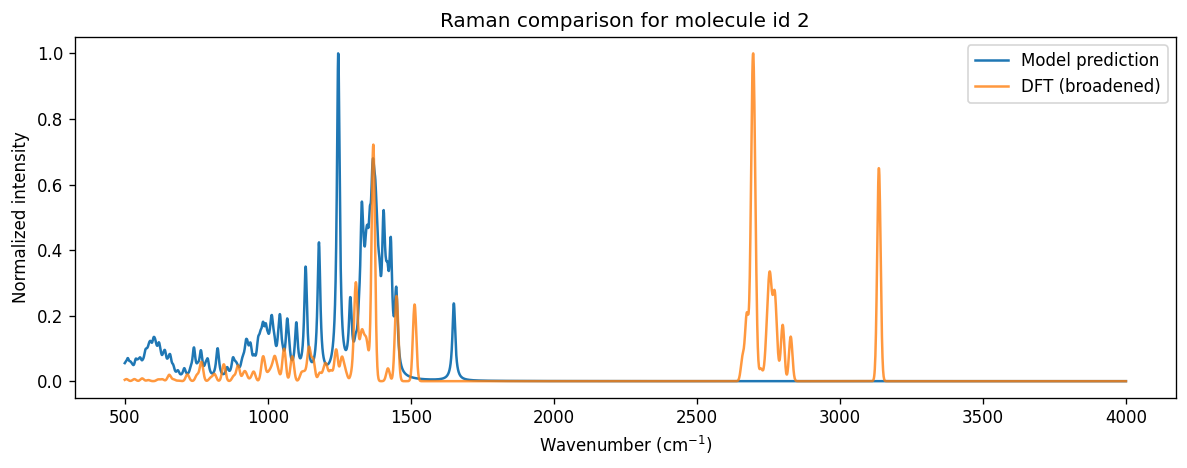

row=2 id=3 metrics={'mse': np.float64(0.015155870533680244), 'mae': np.float64(0.05055437523510914), 'pearson': np.float64(0.2105661343168839), 'cosine': 0.30740727860412675}


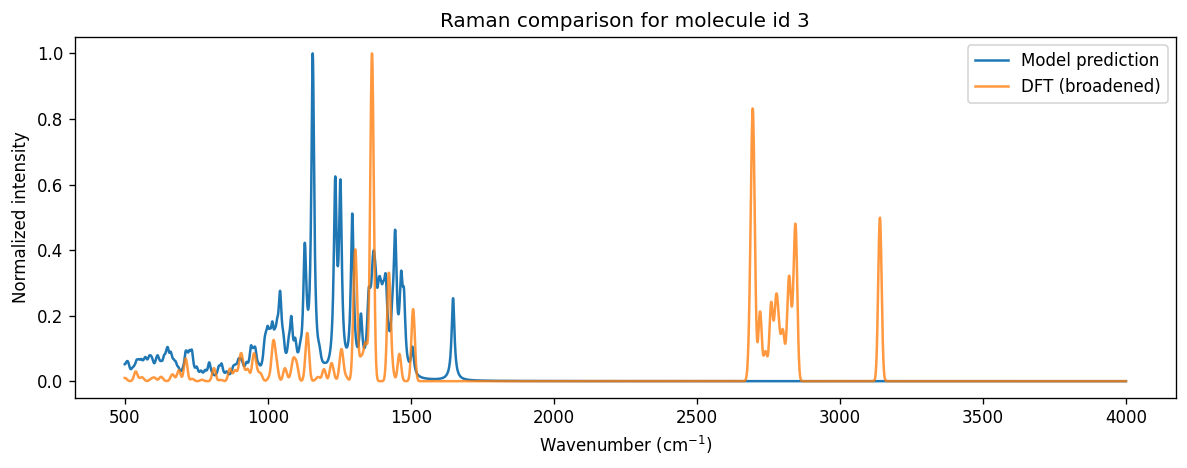

row=3 id=4 metrics={'mse': np.float64(0.03976148091125381), 'mae': np.float64(0.08613148123213879), 'pearson': np.float64(-0.0161485593385517), 'cosine': 0.11279683226200926}


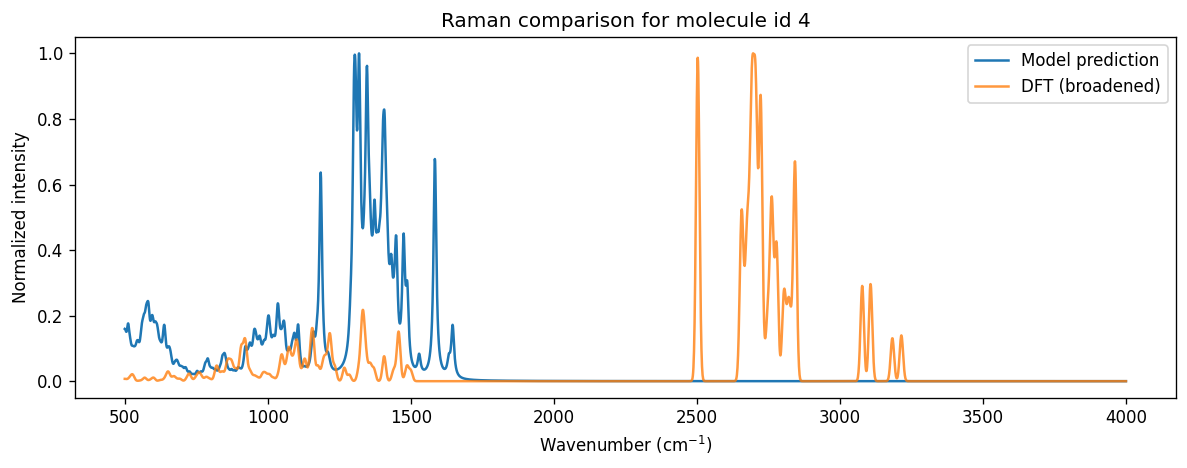

row=4 id=5 metrics={'mse': np.float64(0.02276658513226864), 'mae': np.float64(0.06787549897528952), 'pearson': np.float64(-0.013040860452109282), 'cosine': 0.10000099600290276}


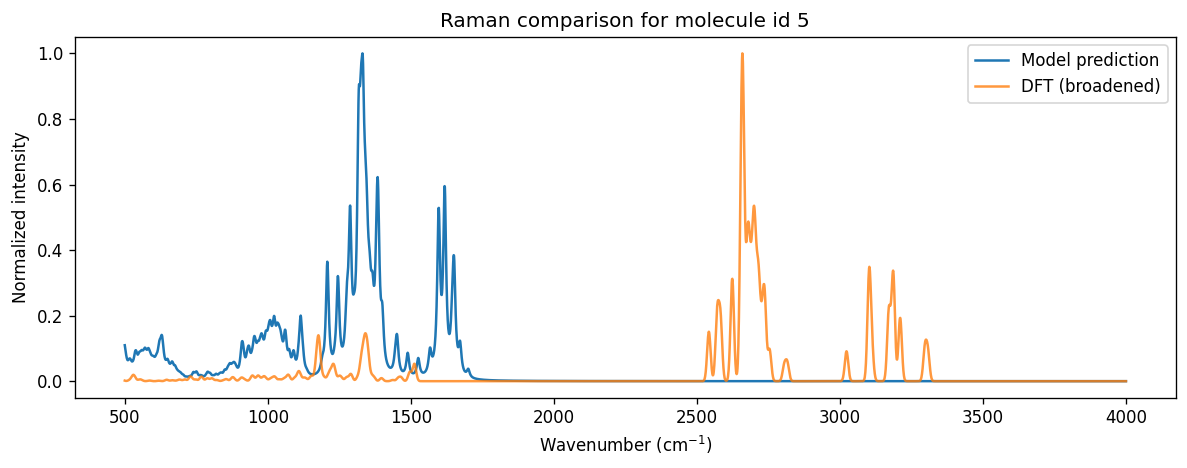

In [8]:
# Batch plot a slice of prediction rows.
# Adjust max_plots/start_index/step to control how many plots you see.
max_plots = 5
start_index = 0
step = 1

plotted = 0
for idx in range(start_index, len(pred_df), step):
    if plotted >= max_plots:
        break
    row = pred_df.iloc[idx]
    try:
        example_id, x_pred, y_pred, y_dft = build_comparison(row, db_path, width, freq_scale, kernel)
    except ValueError as exc:
        print(f'Skipping row {idx}: {exc}')
        continue

    metrics = spectral_metrics(y_pred, y_dft)
    print(f'row={idx} id={example_id} metrics={metrics}')
    plot_spectra(example_id, x_pred, y_pred, y_dft)
    plotted += 1

In [9]:
# Optional: quick batch comparison on a subset
# Increase max_rows if you want a broader evaluation.
max_rows = 50
rows = pred_df.head(max_rows)

all_metrics = []
with sqlite3.connect(db_path) as conn:
    for _, row in rows.iterrows():
        molecule_id = int(row['id'])
        x_pred = row['pred_x']
        y_pred = normalize(row['pred_y'])

        freqs, intensities = get_dft_freqs_intensities(conn, molecule_id)
        if freqs is None:
            continue

        y_dft = lorentzian_spectrum(freqs, intensities, x_pred, gamma=0.5)
        y_dft = normalize(y_dft)

        m = spectral_metrics(y_pred, y_dft)
        m['id'] = molecule_id
        all_metrics.append(m)

metrics_df = pd.DataFrame(all_metrics)
metrics_df.describe()


,mse,mae,pearson,cosine,id
count,50.000000,50.000000,50.000000,50.000000,50.00000
mean,0.015243,0.044843,0.008618,0.058100,25.50000
std,0.007505,0.015918,0.028922,0.032969,14.57738
min,0.004869,0.018414,-0.027023,0.011747,1.00000
25%,0.009923,0.032129,-0.009504,0.037181,13.25000
50%,0.013732,0.044246,0.001060,0.050247,25.50000
75%,0.019946,0.052839,0.017263,0.068402,37.75000
max,0.035727,0.090623,0.126203,0.202241,50.00000
